In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
# Read in data from the Nulisa assay
# which was sent to us by 
df = pd.read_excel('../data/NULISA_for_upload.xlsx')
df.columns

Index(['targetName', 'P08_C1_D1_BMA', 'P08_C1_D1_PB', 'P08_C7_D1_BMA',
       'P08_C7_D1_PB', 'P24_C1_D1_BMA', 'P24_C1_D1_PB', 'P24_C7_D1_BMA',
       'P24_C7_D1_PB', 'P12_C1_D1_BMA', 'P12_C1_D1_PB', 'P12_C12_D29_BMA',
       'P12_C7_D1_BMA', 'P12_C7_D1_PB', 'P04_C1_D1_BMA', 'P04_C1_D1_PB',
       'P04_C12_D29_BMA', 'P04_C12_D29_PB', 'P04_C7_D1_BMA', 'P04_C7_D1_PB',
       'P03_C1_D1_BMA', 'P03_C1_D1_PB', 'P03_C12_D29_BMA', 'P03_C7_D1_BMA',
       'P03_C7_D1_PB', 'P09_C1_D1_BMA', 'P09_C1_D1_PB', 'P09_C12_D29_BMA',
       'P09_C7_D1_BMA', 'P09_C7_D1_PB', 'P10_C1_D1_BMA', 'P10_C1_D1_PB',
       'P10_C12_D29_BMA', 'P10_C7_D1_BMA', 'P10_C7_D1_PB', 'P16_C1_D1_BMA',
       'P16_C1_D1_PB', 'P16_C7_D1_BMA', 'P16_C7_D1_PB', 'P14_C1_D1_BMA',
       'P05_C1_D1_BMA', 'P05_C12_D29_BMA', 'P02_C1_D1_BMA', 'P02_C1_D1_PB',
       'P02_C7_D1_BMA', 'P02_C7_D1_PB', 'P01_C1_D1_BMA', 'P01_C1_D1_PB',
       'P01_C12_D29_BMA', 'P01_C7_D1_BMA', 'P01_C7_D1_PB', 'P11_C1_D1_BMA',
       'P11_C1_D1_PB', 'P11_C12_D

In [3]:
# Transpose the df so that it easier to work with 
df.index = df['targetName']
df = df.iloc[:, 1:]
df = df.T
df

# select blood and bone marrow samples from the oral aza trial (these have _BMA or _PB in the title and lack 'RN')
df = df.loc[(df.index.str.contains('_BMA') | df.index.str.contains('_PB'))  & (~df.index.str.contains('RN')), :]

df.head()

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,TREM1,TREM2,VCAM1,VEGFA,VEGFC,VEGFD,VSNL1,VSTM1,WNT16,WNT7A
P08_C1_D1_BMA,8.098874,7.261311,11.176965,8.961332,9.855022,8.826391,10.476133,10.957482,6.862759,8.990968,...,8.726599,7.940766,9.272499,11.652502,10.575666,8.022063,9.163231,10.833751,9.306676,6.368683
P08_C1_D1_PB,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,13.143437,12.017396,12.941936,15.142156,13.385485,7.592040,11.853413,14.683010,12.931866,8.744185
P08_C7_D1_BMA,10.048087,9.653722,11.570059,9.927943,9.068268,9.235046,9.005682,11.481258,7.992722,9.794737,...,9.923594,9.151399,10.754465,11.196261,10.928972,7.842120,9.814674,11.318856,10.098527,7.128281
P08_C7_D1_PB,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,12.639026,12.237741,13.337745,14.208861,13.273854,7.704273,11.770859,11.012886,13.143388,8.900478
P24_C1_D1_BMA,10.186972,9.498240,11.134398,11.676046,9.376385,9.196032,7.792804,11.939582,9.500984,10.703933,...,10.474709,9.921123,11.156053,11.185332,11.645861,7.479362,9.699821,9.703087,9.618251,7.059484


In [4]:
# Add some useful details to the dataframe, this information is encoded in the sample name (index)
# and added to the df using for loops
samp = ['BMA' if 'BMA' in i else 'PB' for i in df.index]
df['sample_type'] = samp
del samp

timepoint = ['C1D1' if 'C1_D1' in i else 'C7D1' if 'C7_D1' in i else 'C12D29' if 'C12_D29' in i else None for i in df.index]

df['timepoint'] = timepoint
del timepoint


pid = [re.sub('_C\d{1,2}_D\d{1,2}|_BMA|_PB|_', '', i) for i in df.index]

pid = [i.split('_')[0] for i in df.index]

df['pid'] = pid

del pid

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6636/1129097596.py:13: SyntaxWarning: invalid escape sequence '\d'
  pid = [re.sub('_C\d{1,2}_D\d{1,2}|_BMA|_PB|_', '', i) for i in df.index]


In [5]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows = 40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]

# # Create dictionaries so that I can add information to the dataframe such as 
# # diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))
outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))
outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))
    
# # # Use the dictionaries to add clinical outcomes to the dataframe
df['diagnosis'] = df['pid'].map(diagnosis_dx)
df['outcome_6'] = df['pid'].map(outcome_C6_dx)
df['outcome_12'] = df['pid'].map(outcome_C12_dx)    

# Add a column called best coutcome, in which any patient who was a responder at any timepoint 
# gets called a responder
best_out = []
for x, y in zip(df['outcome_6'], df['outcome_12']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_out.append('responder')
    else:
        best_out.append('non_responder')
        
df['best_outcome'] = best_out


In [6]:
outcome_C12_dx

{'P08': 'non-responder_2',
 'P24': nan,
 'P19': nan,
 'P39': nan,
 'P12': 'responder_1',
 'P04': 'non-responder_2',
 'P03': 'responder_1',
 'P27': nan,
 'P09': 'responder_1',
 'P38': nan,
 'P06': 'non-responder_2',
 'P10': 'non-responder_2',
 'P16': 'non-responder_2',
 'P14': 'non-responder_2',
 'P05': 'non-responder_2',
 'P02': 'non-responder_2',
 'P01': 'responder_1',
 'P11': 'responder_1',
 'P28': nan,
 'P07': 'responder_1',
 'P15': 'responder_1',
 'P20': 'responder_1',
 'P17': 'non-responder_2',
 'P18': 'non-responder_2',
 'P22': nan,
 'P25': nan,
 'P13': 'responder_1',
 'P21': 'non-responder_2'}

In [7]:
# Add a time column to allow for easy plotting, 
# then add jitter to permit easy plotting
time = {'C1D1': 1,  'C7D1': 2, 'C12D29': 3}
df['time'] = df['timepoint'].map(time)

jitter_amount = 0.75  # Adjust the jitter amount as needed
x_jitter = np.random.normal(1, jitter_amount, size = df.shape[0])
timejitter =  []
for x, y in zip(df['time'], x_jitter): 
    if x % 2 == 0:
        timejitter.append(x + (y/25))
    else:
        timejitter.append(x - (y/25))

df['time1'] = timejitter

In [8]:
# Rename the outcomes to something easier to type and consequently plot
df[['outcome_6', 'outcome_12']] = df[['outcome_6', 'outcome_12']].apply(lambda x: x.str.replace('responder_1', 'responder'))
df[['outcome_6', 'outcome_12']] = df[['outcome_6', 'outcome_12']].apply(lambda x: x.str.replace('non-responder_2', 'non_responder'))

In [9]:
# Read in timepoint outcomes so that I can find patients who progressed
time_df = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')

time_to_keep = ['Screening', 'C1D1','C7D1', 'C12D29', 'Progression']
time_df = time_df.loc[time_df['Cycle_day'].isin(time_to_keep),:]
time_df['Cycle_day'].value_counts()


Cycle_day
Screening      40
C1D1           40
C7D1           24
Progression    12
C12D29         11
Name: count, dtype: int64

In [10]:
import re

def text_to_int(text_obj):
    # Get the text content from the text object
    text_content = text_obj.get_text()
    
    # Replace Unicode minus sign (U+2212) with ASCII minus sign
    text_content = text_content.replace('\u2212', '-')
    
    # Remove any non-digit characters, but keep the minus sign at the beginning if present
    cleaned_text = re.sub(r'^-?\D*(-?\d+).*$', r'\1', text_content)
    cleaned_text = cleaned_text.replace("''", "")
    try:
        # Try to convert the cleaned string to an integer
        return int(cleaned_text)
    except ValueError:
        print(f"Could not convert '{text_content}' to an integer.")
        return None


In [11]:
# Create a function to add significance stars to a graph
def add_significance_stars(ax, x, y, p_value, is_responder, fontsize=8):
    if p_value < 0.0001:
        text = '****'
    elif p_value < 0.001:
        text = '***'
    elif p_value < 0.01:
        text = '**'
    elif p_value < 0.05:
        text = '*'
    else:
        return
    
    if is_responder:
        y_pos = ax.get_ylim()[1] *0.9 # Get the upper y-limit
        va = 'bottom'
    else:
        y_pos = ax.get_ylim()[1] * -0.75  # Get the lower y-limit
        va = 'top'
    
    ax.text(x, y_pos, text, ha='center', va=va, fontsize=fontsize)


In [12]:
# Create a dataframe with only blood values
df_pb = df.loc[df.index.str.contains('PB'), :]
df_pb.shape

(35, 256)

In [13]:
# Read in a df of p-values which was made from the powerpoint which Bofei sent me
# then update this df to make for easy plotting with highest p-values on the left of the graph, and molecules 
# which went down on the left of the graph
pvals = pd.read_csv('../data/blood_responder_pvals.csv')

to_keep = ['CSF3R', 'MPO', 'GZMB']
# Filter list to keep
pvals = pvals.loc[(pvals['p_val'] <= 0.035) & ~(pvals['Molecule'].isin(to_keep)),  :]
pvals = pvals.sort_values(by ='p_val')

# Create a new df which contains the molecules which went down in the blood of responders
# or changed in the blood of non-responders
pvals1 = pd.read_csv('../data/blood_responder_pvals.csv')
pvals1 = pvals1.loc[pvals1['Molecule'].isin(to_keep), :]

# Concatenate the two dfs 
pvals = pd.concat([pvals, pvals1], axis = 0)

# Add a column called resp which details whether the molecule changed in responder or in non-responders
resp = [True if i != 'GZMB' else False for i in pvals['Molecule']]
pvals['resp'] = resp

del pvals1
del resp

In [14]:
# Create a function to add significance stars to a graph
def add_significance_stars_rotated(ax, x, y, p_value, is_responder, fontsize=8):
    if p_value < 0.0001:
        text = '****'
    elif p_value < 0.001:
        text = '***'
    elif p_value < 0.01:
        text = '**'
    elif p_value < 0.05:
        text = '*'
    else:
        return
    
    if is_responder:
        x_pos = ax.get_xlim()[1] * 0.9  # Get the right x-limit
        ha = 'left'
    else:
        x_pos = ax.get_xlim()[0] * 0.9  # Get the left x-limit
        ha = 'right'
    
    ax.text(x_pos, y, text, ha=ha, va='center', fontsize=fontsize)  # Changed to use ha variable and fixed va

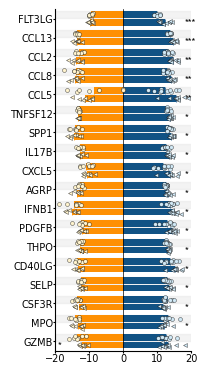

In [16]:
fig, ax = plt.subplots(figsize=(1.9, 6.6/1.85))

plt.rcParams.update({
    'font.family': 'Arial',
    'svg.fonttype': 'none',
    'pdf.fonttype': 'truetype'
})

# Define colors and markers
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

dot_colors = {'non_responder': '#FFF3CD', 'responder': '#D0E8F5'}


markers = {'C1D1': 'o', 'C7D1': '<'}

# Categories and y-axis positions
categories = pvals['Molecule'].to_list()[::-1]
y_positions = np.arange(len(categories))

bar_width = 0.35
time_offsets = {'C1D1': bar_width/2 + 0.025, 'C7D1': -bar_width/2 - 0.025}

mean_values = df_pb.groupby(['outcome_6', 'timepoint'])[categories].mean()

# Draw grey background bars once, for both time offsets, spanning full x-axis
for offset in time_offsets.values():
    if offset >= 0:
        ax.barh(y_positions + offset, left=-20, width=40,
            height=bar_width,
            facecolor='lightgrey', edgecolor='lightgrey',
            alpha=0.25, zorder=0)

# Plot bars and scatter for each outcome and timepoint
for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]

        ax.barh(y_positions + offset, values * multiplier,
                height=bar_width,
                facecolor=colors[outcome], edgecolor=None,
                alpha=1, label=f'{outcome} - {time}', zorder=2)

        ax.vlines(values * multiplier,
                  ymin=y_positions + offset - bar_width/2,
                  ymax=y_positions + offset + bar_width/2,
                  colors=colors[outcome],
                  linewidth=0.75, alpha=0.75, zorder=3)

        subset = df_pb[(df_pb['outcome_6'] == outcome) & (df_pb['timepoint'] == time)]
        for i, category in enumerate(categories):
            y_jitter = np.random.normal(0, 0.05, size=len(subset))
            ax.scatter(subset[category] * multiplier,
                       y_positions[i] + offset + y_jitter,
                       marker=markers[time],
                       facecolor=dot_colors[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=8, zorder=4)

# Axes formatting
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_xlim(-20, 20)
ax.set_ylim(-0.5, len(categories) - 0.5)
ax.set_yticks(y_positions)
ax.set_yticklabels(categories, fontsize=7)
ax.tick_params(axis='both', labelsize=7, pad=0.1, length=1.5)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Significance stars
for i, category in enumerate(categories):
    p_value = pvals.loc[pvals['Molecule'] == category, 'p_val'].values
    is_responder = pvals.loc[pvals['Molecule'] == category, 'resp'].values
    add_significance_stars_rotated(ax, 0, y_positions[i] - bar_width/2,
                                   p_value, is_responder=is_responder, fontsize=7)

fig.tight_layout(pad=0.1)
fig.savefig('../graphs/c1d1_v_c7d1_blood_plot_rotated.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)

In [17]:
# Read in a df of p-values which was made from the powerpoint which Bofei sent me
# then update this df to make for easy plotting with highest p-values on the left of the graph, and molecules 
# which went down on the left of the graph
pvals = pd.read_csv('../data/bm_responder_pvals.csv')

to_keep = ['IL12p70']
# Filter list to keep values below a certain threshold

pvals = pvals.loc[(pvals['p_value'] <= 0.035) & ~(pvals['Molecule'].isin(to_keep)),  :]
pvals = pvals.sort_values(by ='p_value')

# Create a new df which contains the molecules which went down in the blood of responders
# or changed in the blood of non-responders
pvals1 = pd.read_csv('../data/bm_responder_pvals.csv')
pvals1 = pvals1.loc[pvals1['Molecule'].isin(to_keep), :]
# # Concatenate the two dfs 
pvals = pd.concat([pvals, pvals1], axis = 0)

# # # Add a column called resp which details whether the molecule changed in responder or in non-responders
resp = [True if i != 'IL12p70' else False for i in pvals['Molecule']]
pvals['resp'] = resp

del pvals1
del resp

In [18]:
# Read in protein concentration so that we can correct for the protein concentration
p_conc = pd.read_csv('../data/unsw_australia_plasma_protein_concentration_patient_updated.csv')
p_conc = p_conc.loc[:, ['PID_timepoint', 'Protein_concentration (mg/ml)']]
p_conc['PID_timepoint'] = p_conc['PID_timepoint'].str.replace('_BMA', '')

# # Calculate the mean of the column
column_mean = p_conc['Protein_concentration (mg/ml)'].mean()

# # Create a list of the mean value with the same length as the DataFrame so that I can correct for the protein concentraion
mean_list = [column_mean] * len(p_conc)
p_conc['mean'] = mean_list

# # Correct for protein concentration and then 
p_conc['npc'] = p_conc['Protein_concentration (mg/ml)'].div(p_conc['mean'], axis=0)
p_conc['npc_log'] = np.log2(p_conc['npc'])
p_conc.tail()

,PID_timepoint,Protein_concentration (mg/ml),mean,npc,npc_log
41,P13_C12_D29,3.600000,7.136892,0.504421,-0.987299
42,P13_C1_D1,6.192046,7.136892,0.867611,-0.204880
43,P13_C7_D1,5.143165,7.136892,0.720645,-0.472639
44,P21_C1_D1,4.979721,7.136892,0.697744,-0.519231
45,P21_C7_D1,5.319786,7.136892,0.745393,-0.423928


In [19]:
# Merge df_bm with the protein concentration
# Create a dataframe with only blood values
df_bm = df.loc[df.index.str.contains('BMA'), :]
df_bm.index = df_bm.index.str.replace('_BMA', '')

df_bm1 = pd.merge(df_bm, p_conc, left_index=True, right_on= 'PID_timepoint')
# df_bm1.head()
                  

In [20]:
selected_columns = [i for e, i in enumerate(df_bm1.columns) if e <= 246]

df_bm1[selected_columns] = df_bm1[selected_columns].sub(df_bm1['npc_log'], axis=0)


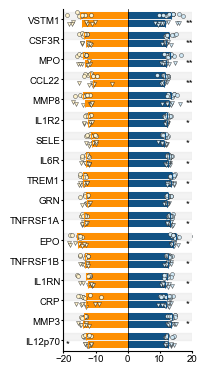

In [21]:
# Make a graph with the bone data corrected
#fig, ax = plt.subplots(figsize=(1.9, 6.6/2.1))
fig, ax = plt.subplots(figsize=(1.9, 6.6/1.5))
# Swapped dimensions
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text
# Define colors for different times
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

dot_colors = {'non_responder': '#FFF3CD', 'responder': '#D0E8F5'}


markers = {'C1D1': 'o', 'C7D1': 'v'}
# Define the categories and their positions on the y-axis now
categories = pvals['Molecule'].to_list()[::-1]
y_positions = np.arange(len(categories))
# Set the width of each bar
bar_width = 0.35
mean_values = df_pb.groupby(['outcome_6', 'timepoint'])[categories].mean()



time_offsets = {'C1D1': bar_width/2 + 0.025, 'C7D1': -bar_width/2 - 0.025}

# Draw grey background bars once, for both time offsets, spanning full x-axis
for offset in time_offsets.values():
    if offset >= 0:
        ax.barh(y_positions + offset, left=-20, width=40,
            height=bar_width,
            facecolor='lightgrey', edgecolor='lightgrey',
            alpha=0.25, zorder=0)


for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1

    
    for time, offset in time_offsets.items():
        alp = 1.0 #if time == 'C7D1' else 0.5
        values = mean_values.loc[outcome, time]

        ax.barh(y_positions + offset, values * multiplier, bar_width,
                #facecolor=colors[outcome], edgecolor=None,
                facecolor=colors[outcome], edgecolor=None,
                alpha=1., label=f'{outcome} - {time}', zorder=2)
        
        for i, category in enumerate(categories):
            subset = df_pb[(df_pb['outcome_6'] == outcome) & (df_pb['timepoint'] == time)]
            y_jitter = np.random.normal(0, 0.05, size=len(subset))
            ax.scatter(subset[category] * multiplier,
                       y_positions[i] + offset + y_jitter,
                       marker=markers[time],
                       facecolor=dot_colors[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=8, zorder=2)

        
        ax.vlines(values * multiplier,
                  ymin=y_positions + offset - bar_width/2,
                  ymax=y_positions + offset + bar_width/2,
                  colors=colors[outcome],
                  linewidth=0.75, zorder=3)

# Add a vertical line to the graph (previously horizontal)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Set labels and ticks
ax.set_yticks(range(len(categories)))

ax.set_yticklabels(categories, rotation=0)
ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5)    
ax.set_ylim(-0.5, len(categories) -0.5)
ax.set_xlim(-20, 20)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add significance stars after setting the x-limits
for i, category in enumerate(categories):
    p_value = pvals.loc[pvals['Molecule'] == category, 'p_value'].values
    add_significance_stars_rotated(ax, 0, y_positions[i] - bar_width/2, p_value, 
                                 is_responder=pvals.loc[pvals['Molecule'] == category, 'resp'].values, 
                                 fontsize=7)

#fig.set_size_inches(1.9, 6.6/2.1)
fig.set_size_inches(1.9, 6.6/1.85)
fig.tight_layout(pad=0.1)
fig.savefig('../graphs/c1d1_v_c7d1_bone_marrow_plot_rotated_.pdf', bbox_inches = 'tight', pad_inches=0.01, dpi=300)